In [1]:
import pandasql as ps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df1 = pd.read_csv('healthcareTest.csv')
df2 = pd.read_csv('healthcareTrain.csv')

In [3]:
df1.head()

,patIndex,pdc,num_ip_post,total_los_post,num_op_post,num_er_post,num_ndc_post,num_gpi6_post,adjust_total_30d_post,generic_rate_post,...,brand_cost,ratio_G_total_cost,numofgen_post,numofbrand_post,generic_cost_post,brand_cost_post,ratio_G_total_cost_post,pdc_80_flag,drug_class,patient_key
0,2,0.333333,0,0,4,0,15,5,14.466667,0.101382,...,2984.927229,0.010155,2,13,196.359216,3001.501507,0.061403,0,*ANTIDIABETICS*,168
1,5,0.866667,0,0,5,0,16,4,18.000000,0.888889,...,0.000000,1.000000,14,2,671.755173,735.661568,0.477297,1,*ANTIDIABETICS*,499
2,21,0.500000,0,0,0,0,8,6,8.000000,0.875000,...,0.000000,1.000000,7,1,50.160767,41.220633,0.548917,0,*ANTIDIABETICS*,1830
3,22,0.977778,0,0,9,0,40,9,42.533333,0.835423,...,1345.104492,0.339094,33,7,842.908516,1695.649323,0.332042,1,*ANTIDIABETICS*,1852
4,33,0.527778,0,0,6,0,28,7,28.000000,0.964286,...,0.000000,1.000000,27,1,1163.290225,6.514435,0.994431,0,*ANTIDIABETICS*,3369


In [4]:
df2.head()

,patIndex,pdc,num_ip_post,total_los_post,num_op_post,num_er_post,num_ndc_post,num_gpi6_post,adjust_total_30d_post,generic_rate_post,...,brand_cost,ratio_G_total_cost,numofgen_post,numofbrand_post,generic_cost_post,brand_cost_post,ratio_G_total_cost_post,pdc_80_flag,drug_class,patient_key
0,2393,0.500000,0,0,2,0,3,2,2.333333,1.0,...,0.000000,1.000000,3,0,39.557654,0.0,1.0,0,*ANTIDIABETICS*,322512
1,2148,0.994444,0,0,3,0,17,5,26.500000,1.0,...,19.553557,0.929937,17,0,547.646290,0.0,1.0,1,*ANTIDIABETICS*,291191
2,1799,0.472222,0,0,3,0,3,1,3.000000,1.0,...,0.000000,1.000000,3,0,8.834483,0.0,1.0,0,*ANTIDIABETICS*,251767
3,636,0.166667,0,0,0,0,2,2,2.000000,1.0,...,243.805101,NaN,2,0,8.100969,0.0,1.0,0,*ANTIDIABETICS*,80678
4,114,0.944444,0,0,3,0,12,2,12.000000,1.0,...,0.000000,1.000000,12,0,50.324328,0.0,1.0,1,*ANTIDIABETICS*,16047


In [5]:
df_clean = df1[['pdc', 'pdc_80_flag', 'numofgen_post', 'numofbrand_post', 'drug_class']].dropna()


In [6]:
df_clean = df_clean.astype({
    'pdc':'float',
    'pdc_80_flag':'int',
    'numofgen_post':'int',
    'numofbrand_post':'int'
})

In [7]:
df_clean.head()

,pdc,pdc_80_flag,numofgen_post,numofbrand_post,drug_class
0,0.333333,0,2,13,*ANTIDIABETICS*
1,0.866667,1,14,2,*ANTIDIABETICS*
2,0.500000,0,7,1,*ANTIDIABETICS*
3,0.977778,1,33,7,*ANTIDIABETICS*
4,0.527778,0,27,1,*ANTIDIABETICS*


In [8]:
#What % of patients are non-adherent (pdc < 0.8) ?
Query = """
SELECT COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df_clean) AS non_adherent_percent
FROM df_clean
WHERE pdc < 0.8
"""


In [9]:
result = ps.sqldf(Query, locals())

In [10]:
result

,non_adherent_percent
0,62.5


In [11]:
#Average number of generuc vs brand medications used
Query2 = """
SELECT 
AVG(numofgen_post) as avg_generic_meds,
AVG(numofbrand_post) as avg_brand_meds
FROM df_clean
"""

In [12]:
result2 = ps.sqldf(Query2, locals())

In [13]:
result2

,avg_generic_meds,avg_brand_meds
0,12.200581,4.656977


In [14]:
#Distribution of adherence flag
Query3 = """
SELECT pdc_80_flag, COUNT(*) AS count
FROM df_clean
GROUP BY pdc_80_flag
"""

In [15]:
result3 = ps.sqldf(Query3, locals())

In [16]:
result3

,pdc_80_flag,count
0,0,215
1,1,129


In [17]:
#Summary Statistics 
Query4 = """ 
SELECT 
COUNT(*) AS total_records,
COUNT(DISTINCT patient_key) AS unique_patients,
SUM(pdc_80_flag) AS adherent_count,
ROUND(100.0 * SUM(pdc_80_flag) / COUNT(*), 2) as adherence_percent,
COUNT(DISTINCT drug_class) AS drug_class_count
FROM df1;
"""

In [18]:
result4 = ps.sqldf(Query4, locals())

In [19]:
result4

,total_records,unique_patients,adherent_count,adherence_percent,drug_class_count
0,344,344,129,37.5,1


In [22]:
metrices = result4.columns.tolist()
values = result4.iloc[0].tolist()

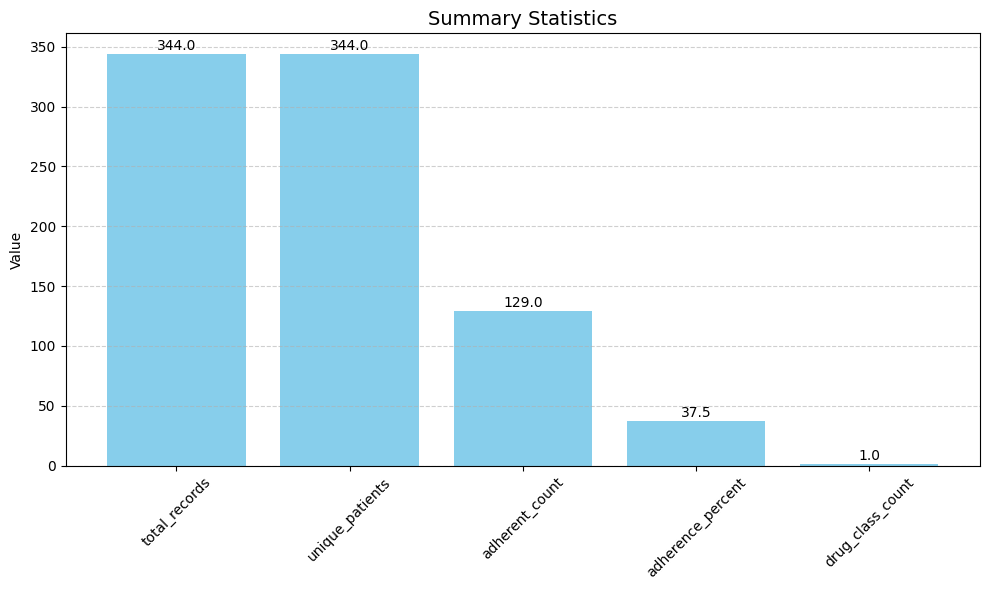

In [25]:
plt.figure(figsize=(10,6))
bars = plt.bar(metrices, values, color='skyblue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}', ha='center', va='bottom')

plt.title("Summary Statistics", fontsize=14)
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [27]:
Query5 = """
SELECT
COUNT(*) AS total_records,
COUNT(DISTINCT patient_key) AS unique_patients,
SUM(pdc_80_flag) AS adherent_count,
ROUND(100.0 * SUM(pdc_80_flag) / COUNT(*), 2) AS adherence_percent, 
COUNT(DISTINCT drug_class) AS drug_class_count
FROM df2;
"""

result5 = ps.sqldf(Query5, locals())
print(result5)

   total_records  unique_patients  adherent_count  adherence_percent  \
0           1378             1378             542              39.33   

   drug_class_count  
0                 1  


In [28]:

metrics = result5.columns.tolist()
values = result5.iloc[0].tolist()

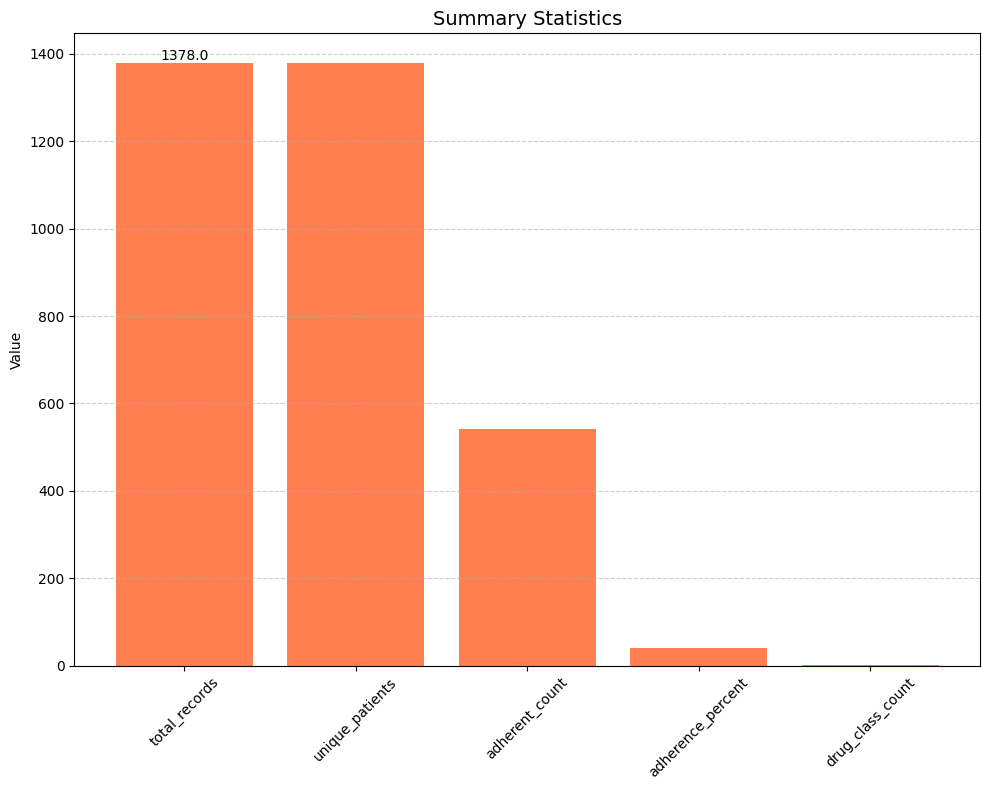

/var/folders/1f/n1d8zkln1nv50975kqltn2h80000gn/T/ipykernel_1969/258719022.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


/var/folders/1f/n1d8zkln1nv50975kqltn2h80000gn/T/ipykernel_1969/258719022.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()




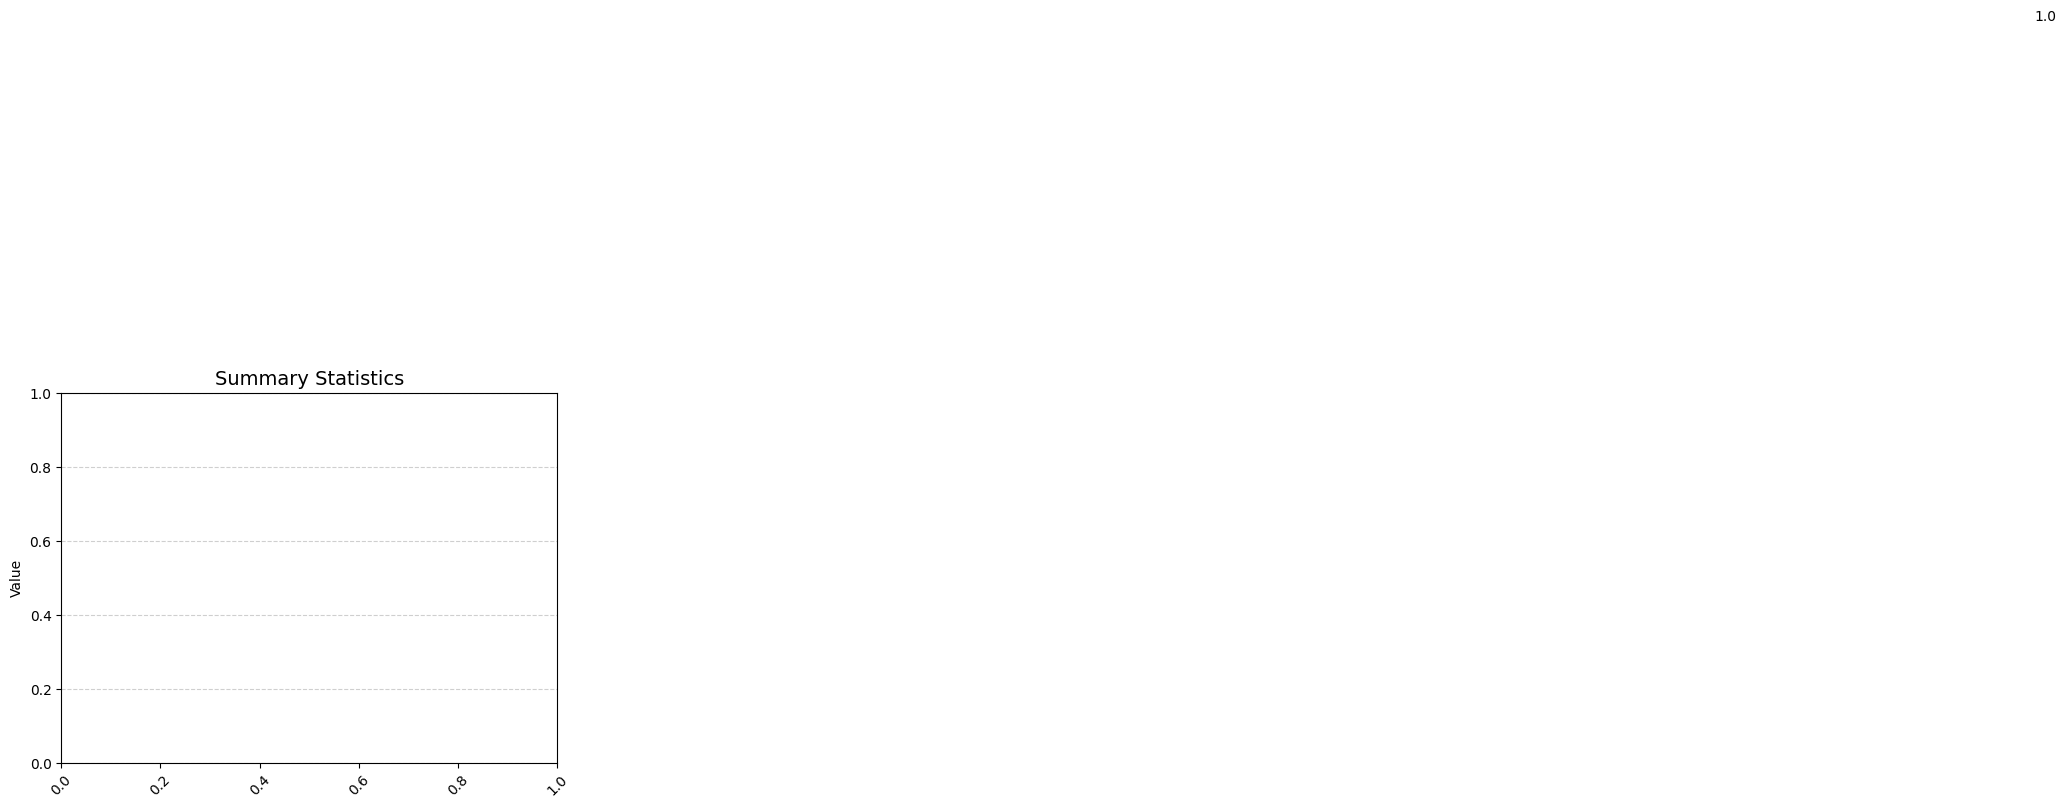

In [29]:
plt.figure(figsize=(10, 8))
bars = plt.bar(metrices, values, color='coral')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1 , f'{height:.1f}', ha='center', va='bottom')

    plt.title("Summary Statistics", fontsize=14)
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

In [30]:
#Total Generic and brand meds
Query6 = """
SELECT 
SUM(numofgen_post) AS total_generic,
SUM(numofbrand_post) AS total_brand
FROM df2;
"""

In [90]:
result6 = ps.sqldf(Query6, locals())

In [91]:
result6

,total_generic,total_brand
0,17469,6780


In [94]:
Query7 = """
SELECT
 SUM(generic_cost_post) AS total_generic_cost,
 SUM(brand_cost_post) AS total_brand_cost
FROM df2;
"""

In [95]:
result7 = ps.sqldf(Query7, locals())
result7

,total_generic_cost,total_brand_cost
0,425867.739423,2.011237e+06


In [96]:
Query8 = """
SELECT 
pdc_80_flag as adherence,
COUNT(*) AS count
FROM df2
GROUP BY pdc_80_flag;
""" 

In [97]:
result8 = ps.sqldf(Query8, locals())
result8

,adherence,count
0,0,836
1,1,542
